# Sharon Entropy

Found 30 DAY*.csv files to process
Processing DAY0.csv (1/30)
Processing DAY1.csv (2/30)
Processing DAY2.csv (3/30)
Processing DAY3.csv (4/30)
Processing DAY4.csv (5/30)
Processing DAY5.csv (6/30)
Processing DAY6.csv (7/30)
Processing DAY7.csv (8/30)
Processing DAY8.csv (9/30)
Processing DAY9.csv (10/30)
Processing DAY10.csv (11/30)
Processing DAY11.csv (12/30)
Processing DAY12.csv (13/30)
Processing DAY13.csv (14/30)
Processing DAY14.csv (15/30)
Processing DAY15.csv (16/30)
Processing DAY16.csv (17/30)
Processing DAY17.csv (18/30)
Processing DAY18.csv (19/30)
Processing DAY19.csv (20/30)
Processing DAY20.csv (21/30)
Processing DAY21.csv (22/30)
Processing DAY22.csv (23/30)
Processing DAY23.csv (24/30)
Processing DAY24.csv (25/30)
Processing DAY25.csv (26/30)
Processing DAY26.csv (27/30)
Processing DAY27.csv (28/30)
Processing DAY28.csv (29/30)
Processing DAY29.csv (30/30)


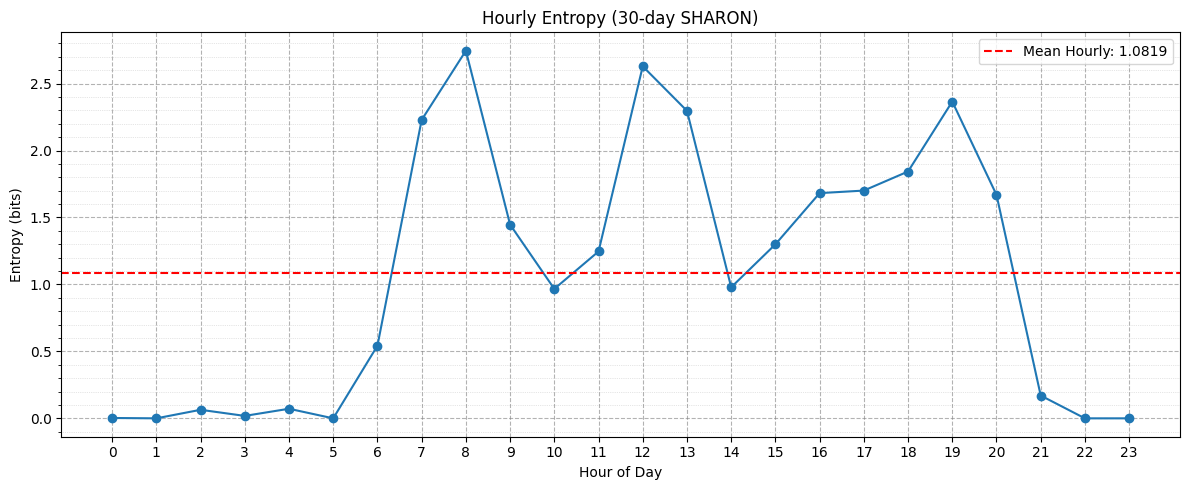


Daily entropy (first few rows):
    Day   Entropy  TotalActivations
0  DAY0  2.883694             90708
1  DAY1  2.876140             90685
2  DAY2  2.878674             91231
3  DAY3  2.906555             90685
4  DAY4  3.033405             93220


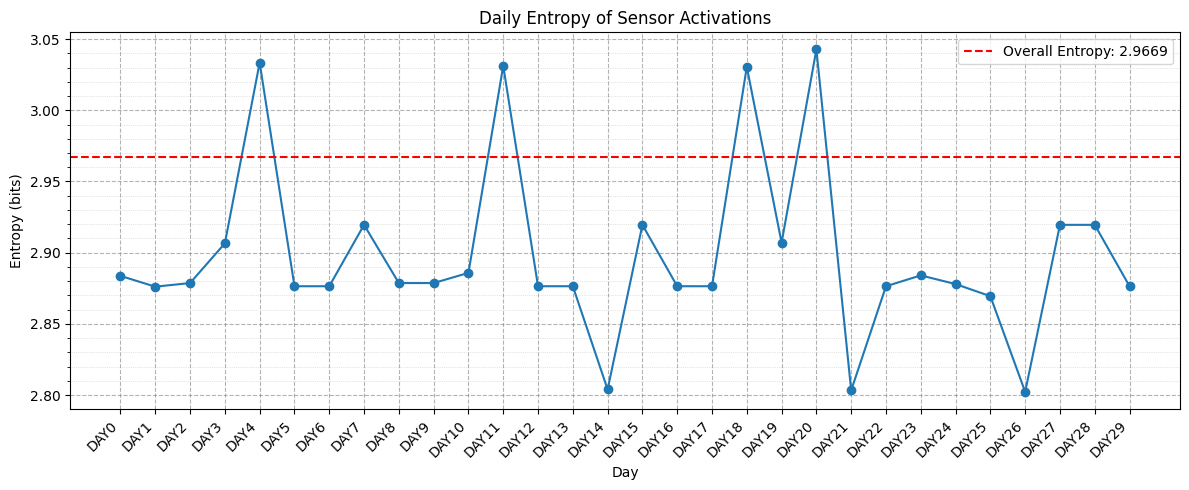

In [1]:
#Importing Libraries
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy
from matplotlib.ticker import AutoMinorLocator

#Plotting helper
def plot_entropy_with_reference(x_values, y_values, overall_value,
                                xlabels=None, title="", xlabel="", ylabel="",
                                ref_label=None):
    """Line plot with a red dashed reference line and visible grids."""
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(x_values, y_values, marker='o')

    if np.isfinite(overall_value):
        label_text = ref_label if ref_label else f'Overall Entropy: {overall_value:.4f}'
        ax.axhline(overall_value, ls='--', color='r', lw=1.5, label=label_text)
        ax.legend()

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if xlabels is not None:
        ax.set_xticks(x_values)
        ax.set_xticklabels(xlabels, rotation=45, ha='right')
    else:
        ax.set_xticks(x_values)

    ax.set_axisbelow(True)
    ax.grid(True, which='major', axis='both', linestyle='--',
            linewidth=0.8, alpha=0.6, color='grey')
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(True, which='minor', axis='y', linestyle=':',
            linewidth=0.5, alpha=0.4, color='grey')

    fig.tight_layout()
    plt.show()


DATA_DIR = '/content/drive/MyDrive/Dissertation/30 days_sensor output'  # folder with DAY*.csv
ENTROPY_BASE = 2  # 2 = bits, np.e = nats

# The sensor columns we expect to find in each daily file
SENSOR_COLUMNS = [
    'BedroomBed','BedroomWardrobe','BedroomDoor',
    'BathBathtub','BathWC','BathSink','BathWashingMachine',
    'BathDoor','ExitDoor',
    'LivingroomChair1','LivingroomChair2','LivingroomSofa1','LivingroomSofa2',
    'LivingroomLight','LivingroomTV',
    'KitchenSink','KitchenCooker','KitchenCupboard','KitchenFridge'
]

# Find only files named like DAY0.csv, DAY1.csv, …
day_files = sorted(
    [f for f in os.listdir(DATA_DIR) if re.match(r'(?i)^day\d+\.csv$', f)],
    key=lambda x: int(re.search(r'(\d+)', x).group())
)
print(f"Found {len(day_files)} DAY*.csv files to process")

# Helper to compute entropy from counts
def entropy_from_counts(counts, base=2):
    """Shannon entropy of a 1D array of counts (returns NaN if total is zero)."""
    total = counts.sum()
    if total == 0:
        return np.nan
    p = counts / total
    return float(entropy(p, base=base))

# Process each day: clean data and compute that day's entropy

daily_rows = []      # will become the daily entropy table
combined_days = []   # to build the "all days combined" view
skipped = []         # files we skip because of bad/missing time column

for idx, fname in enumerate(day_files, start=1):
    print(f"Processing {fname} ({idx}/{len(day_files)})")
    path = os.path.join(DATA_DIR, fname)

    try:
        df = pd.read_csv(path)
    except Exception as ex:
        print(f"  -> Skipping {fname}: could not read file ({ex})")
        skipped.append(fname)
        continue

    # Clean header spaces (e.g., " Time" -> "Time")
    df.columns = df.columns.str.strip()

    # Find a time column (accepts 'Time' in any case or with extra spaces)
    time_col = next((c for c in df.columns if c.strip().lower() == 'time'), None)
    if time_col is None:
        time_candidates = [c for c in df.columns if 'time' in c.strip().lower()]
        time_col = time_candidates[0] if time_candidates else None

    if time_col is None:
        print(f"  -> Skipping {fname}: no 'Time' column found")
        skipped.append(fname)
        continue

    # Parse times; try HH:MM:SS, then HH:MM:SS.sss, then general parser
    t = pd.to_datetime(df[time_col].astype(str).str.strip(),
                       format='%H:%M:%S', errors='coerce')
    if t.isna().all():
        t = pd.to_datetime(df[time_col].astype(str).str.strip(),
                           format='%H:%M:%S.%f', errors='coerce')
    if t.isna().all():
        t = pd.to_datetime(df[time_col].astype(str).str.strip(),
                           errors='coerce')

    if t.isna().all():
        print(f"  -> Skipping {fname}: could not parse any times")
        skipped.append(fname)
        continue

    df['Time'] = t

    missing = [c for c in SENSOR_COLUMNS if c not in df.columns]
    for c in missing:
        df[c] = 0

    df[SENSOR_COLUMNS] = (
        df[SENSOR_COLUMNS]
        .apply(pd.to_numeric, errors='coerce')
        .fillna(0)
        .clip(lower=0, upper=1)
        .astype(int)
    )

    # Count how many times each sensor was active today
    sensor_counts_today = df[SENSOR_COLUMNS].sum()

    # Compute today's entropy (how evenly usage was spread across sensors)
    H_today = entropy_from_counts(sensor_counts_today, base=ENTROPY_BASE)

    daily_rows.append({
        "Day": os.path.splitext(fname)[0],
        "Entropy": H_today,
        "TotalActivations": int(sensor_counts_today.sum())
    })

    # Save for overall stats and hourly analysis later
    df['Day'] = os.path.splitext(fname)[0]
    combined_days.append(df)

# Plotting the graphs
if not combined_days:
    print("\nNo valid DAY files processed.")
    if skipped:
        print("Skipped files:", skipped)
else:
    # Combine all days for overall stats and hour-of-day analysis
    combined_df = pd.concat(combined_days, ignore_index=True)

    # Overall entropy across the entire 30-day period (all sensors combined)
    all_counts = combined_df[SENSOR_COLUMNS].sum()
    overall_entropy = entropy_from_counts(all_counts, base=ENTROPY_BASE)

    # Hour-of-day entropy across the 30 days
    combined_df["Hour"] = combined_df["Time"].dt.hour
    hour_counts = combined_df.groupby("Hour")[SENSOR_COLUMNS].sum()  # 24 x sensors
    # Ensure we have all 24 hours in order
    hour_counts = hour_counts.reindex(range(24), fill_value=0)

    hourly_entropy_table = (
        hour_counts.apply(lambda row: entropy_from_counts(row, base=ENTROPY_BASE), axis=1)
        .rename("Entropy")
        .reset_index()
        .rename(columns={"index": "Hour"})
    )

    ref_value = float(np.nanmean(hourly_entropy_table["Entropy"]))
    ref_label = f"Mean Hourly: {ref_value:.4f}"

    # Plot hour-of-day entropy
    unit_label = "bits" if ENTROPY_BASE == 2 else "nats"
    plot_entropy_with_reference(
        x_values=hourly_entropy_table["Hour"].tolist(),
        y_values=hourly_entropy_table["Entropy"].tolist(),
        overall_value=ref_value,
        xlabels=None,
        title="Hourly Entropy (30-day SHARON)",
        xlabel="Hour of Day",
        ylabel=f"Entropy ({unit_label})",
        ref_label=ref_label
    )

    # Daily entropy table and plot
    daily_entropy_table = pd.DataFrame(daily_rows)
    print("\nDaily entropy (first few rows):")
    print(daily_entropy_table.head())

    x_vals = list(range(1, len(daily_entropy_table) + 1))
    y_vals = daily_entropy_table["Entropy"].tolist()
    day_labels = daily_entropy_table["Day"].tolist()

    plot_entropy_with_reference(
        x_values=x_vals,
        y_values=y_vals,
        overall_value=overall_entropy,
        xlabels=day_labels,
        title="Daily Entropy of Sensor Activations",
        xlabel="Day",
        ylabel=f"Entropy ({unit_label})"
    )



# CASAS Entropy

/tmp/ipython-input-1415099918.py:63: UserWarning: Parsing dates in %d/%m/%Y %H:%S.%f format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ts = pd.to_datetime(f"{date} {time}", errors="raise")


Rows parsed: 40598  |  Using activations only
Pooled overall entropy (bits): 3.1970
Mean hourly entropy: 3.1373


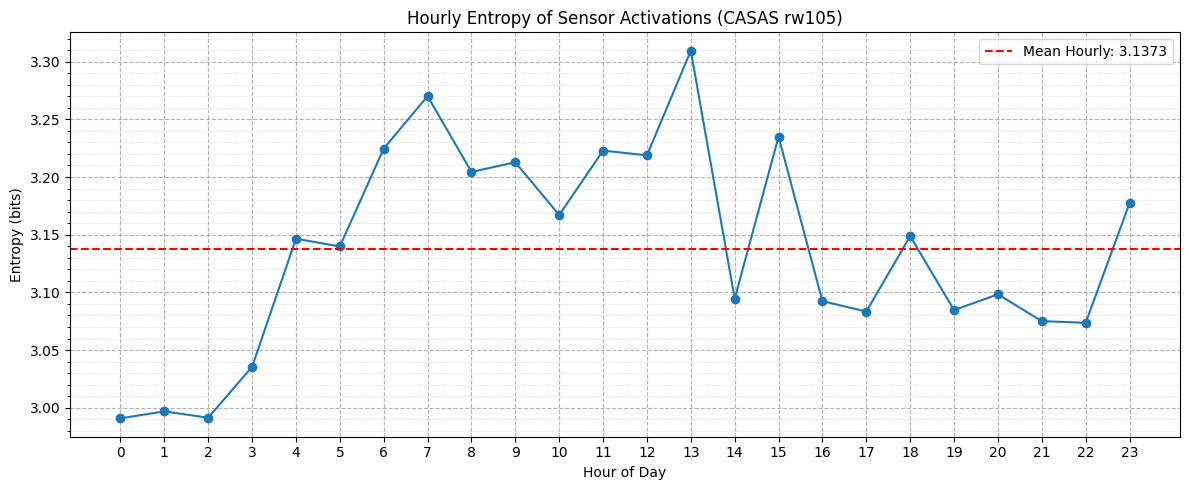

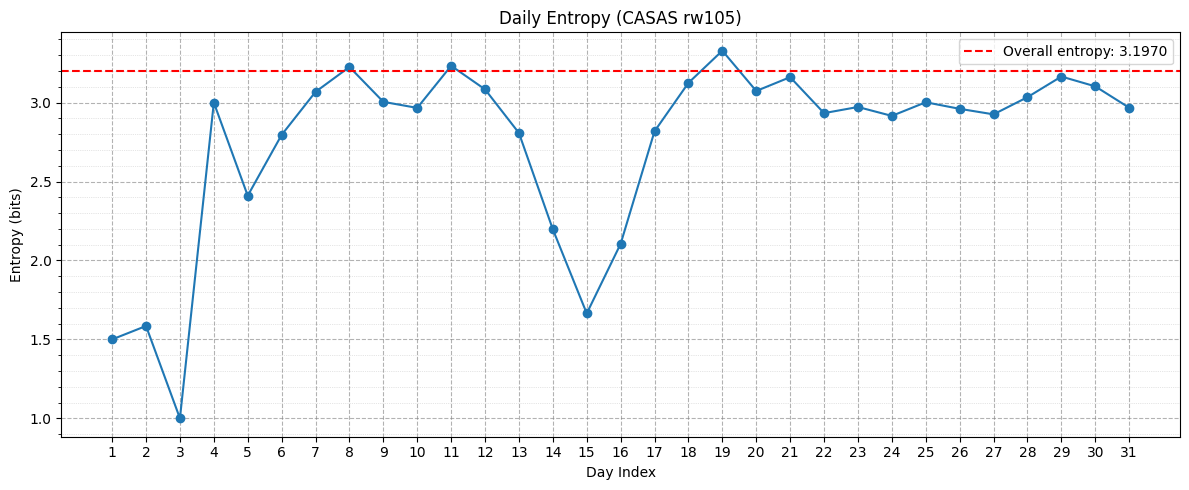

In [ ]:
# Importing Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy
from matplotlib.ticker import AutoMinorLocator

# Plotting helper

def plot_entropy_with_reference(x_values, y_values, ref_value,
                                xlabels=None, title="", xlabel="", ylabel="",
                                ref_label=None):
    """Line plot with a red dashed reference line and visible grids."""
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(x_values, y_values, marker='o')

    if np.isfinite(ref_value):
        ax.axhline(ref_value, ls='--', color='r', lw=1.5,
                   label=(ref_label if ref_label else f'Overall entropy: {ref_value:.4f}'))
        ax.legend()

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if xlabels is not None:
        ax.set_xticks(x_values)
        ax.set_xticklabels(xlabels, rotation=45, ha='right')
    else:
        ax.set_xticks(x_values)

    ax.set_axisbelow(True)
    ax.grid(True, which='major', axis='both', linestyle='--',
            linewidth=0.8, alpha=0.6, color='grey')
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(True, which='minor', axis='y', linestyle=':',
            linewidth=0.5, alpha=0.4, color='grey')

    fig.tight_layout()
    plt.show()

# Settings

CASAS_FILE   = '/content/drive/MyDrive/Dissertation/rw105.csv'
SAVE_DIR     = os.path.join(os.path.dirname(CASAS_FILE), 'results')
ENTROPY_BASE = 2  # 2 = bits; use np.e for nats
os.makedirs(SAVE_DIR, exist_ok=True)

ACTIVATION_TOKENS = {"ON", "OPEN", "PRESENT", "BEGIN", "1", "UP", "ENTER"}

rows = []
with open(CASAS_FILE, "r", encoding="utf-8-sig", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = [p.strip() for p in line.split(",")]
        if len(parts) < 4:
            continue
        date, time, sensor, value = parts[:4]
        try:
            ts = pd.to_datetime(f"{date} {time}", errors="raise")
        except Exception:
            continue
        rows.append((ts, sensor.strip(), value.strip()))

df = pd.DataFrame(rows, columns=["timestamp", "sensor", "value"]).dropna(subset=["timestamp"])
df["sensor"]  = df["sensor"].astype(str).str.strip()
df["value_u"] = df["value"].astype(str).str.upper().str.strip()

# Keep only activation events if present; else keep all events
mask = df["value_u"].isin(ACTIVATION_TOKENS)
df_use = df[mask].copy() if mask.any() else df.copy()

# Hour and date for grouping
df_use["Hour"] = df_use["timestamp"].dt.hour
df_use["Date"] = df_use["timestamp"].dt.date

def entropy_from_counts(counts, base=2):
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts / total
    return float(entropy(p, base=base))

# HOURLY ENTROPY

sensor_counts_by_hour = df_use.groupby(["Hour", "sensor"]).size().unstack(fill_value=0)
hourly_entropy_table = (
    sensor_counts_by_hour.apply(lambda row: entropy_from_counts(row, base=ENTROPY_BASE), axis=1)
    .rename("Entropy")
    .reset_index()
)
# Ensure all 24 hours are present
hourly_entropy_table = (
    pd.DataFrame({"Hour": range(24)})
    .merge(hourly_entropy_table, on="Hour", how="left")
    .fillna(0.0)
)

# DAILY ENTROPY

sensor_counts_by_day = df_use.groupby(["Date", "sensor"]).size().unstack(fill_value=0)
entropy_per_day = (
    sensor_counts_by_day.apply(lambda row: entropy_from_counts(row, base=ENTROPY_BASE), axis=1)
    .rename("Entropy")
    .reset_index()
)

overall_counts  = df_use.groupby("sensor").size()
overall_entropy = entropy_from_counts(overall_counts.values, base=ENTROPY_BASE)

mean_hourly_ref = float(np.nanmean(hourly_entropy_table["Entropy"]))
mean_hourly_lbl = f"Mean Hourly: {mean_hourly_ref:.4f}"

print(f"Rows parsed: {len(df)}  |  Using {'activations only' if mask.any() else 'all events'}")
print(f"Pooled overall entropy ({'bits' if ENTROPY_BASE==2 else 'nats'}): {overall_entropy:.4f}")
print(f"Mean hourly entropy: {mean_hourly_ref:.4f}")

# PLOTS
unit_label = "bits" if ENTROPY_BASE == 2 else "nats"

# Hourly plot
plot_entropy_with_reference(
    x_values=hourly_entropy_table["Hour"].tolist(),
    y_values=hourly_entropy_table["Entropy"].tolist(),
    ref_value=mean_hourly_ref,
    xlabels=None,
    title="Hourly Entropy of Sensor Activations (CASAS rw105)",
    xlabel="Hour of Day",
    ylabel=f"Entropy ({unit_label})",
    ref_label=mean_hourly_lbl
)

# Daily plot
plot_entropy_with_reference(
    x_values=list(range(1, len(entropy_per_day) + 1)),
    y_values=entropy_per_day["Entropy"].tolist(),
    ref_value=overall_entropy,
    xlabels=None,
    title="Daily Entropy (CASAS rw105)",
    xlabel="Day Index",
    ylabel=f"Entropy ({unit_label})"
)

